# Attention + mlp

Dataset shape: (405894, 34)
Epoch 1/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 0.0755 - mae: 0.2309 - val_loss: 0.0336 - val_mae: 0.1329 - learning_rate: 0.0010
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0373 - mae: 0.1480 - val_loss: 0.0252 - val_mae: 0.0988 - learning_rate: 0.0010
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0301 - mae: 0.1291 - val_loss: 0.0184 - val_mae: 0.0833 - learning_rate: 0.0010
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0269 - mae: 0.1192 - val_loss: 0.0162 - val_mae: 0.0811 - learning_rate: 0.0010
Epoch 5/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0235 - mae: 0.1106 - val_loss: 0.0136 - val_mae: 0.0715 - learning_rate: 0.0010
Epoch 6/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0218 - mae: 0.1053 - val_loss: 0.0156 - val_mae: 0.0722 - learning_rate: 0.0010
Epoch 7/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0208 - mae: 0.1013 - val_loss:

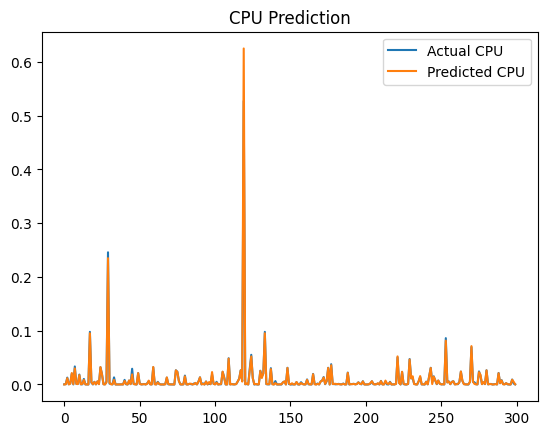

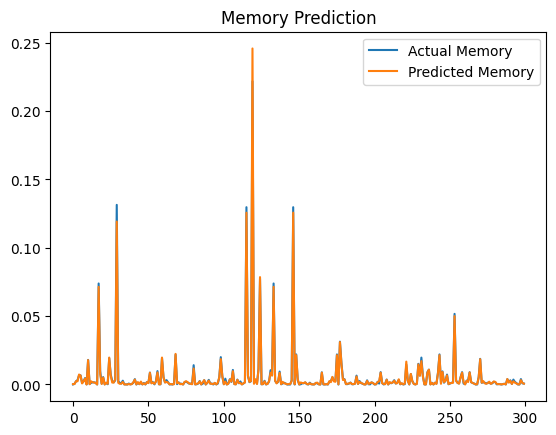

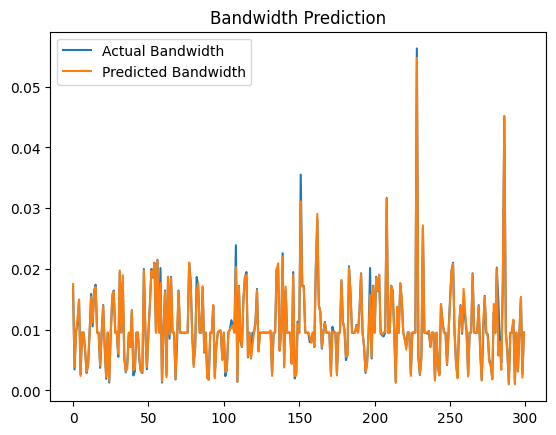

In [1]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Multiply, Softmax
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# =========================================
# 2. LOAD DATA
# =========================================
path = r"C:\Users\hp\Desktop\Major Pr\borg_traces_data.csv"
df = pd.read_csv(path)

print("Dataset shape:", df.shape)


# =========================================
# 3. DROP USELESS COLUMNS
# =========================================
drop_cols = [
    'Unnamed: 0',
    'constraint',
    'user',
    'collection_name',
    'collection_logical_name',
    'start_after_collection_ids',
    'cpu_usage_distribution',
    'tail_cpu_usage_distribution'
]
df.drop(columns=drop_cols, inplace=True, errors='ignore')


# =========================================
# 4. PARSE DICTIONARY COLUMNS
# =========================================
def extract_value(x, key):
    try:
        return ast.literal_eval(x)[key]
    except:
        return np.nan

df['req_cpu'] = df['resource_request'].apply(lambda x: extract_value(x, 'cpus'))
df['req_mem'] = df['resource_request'].apply(lambda x: extract_value(x, 'memory'))

df['avg_cpu'] = df['average_usage'].apply(lambda x: extract_value(x, 'cpus'))
df['avg_mem'] = df['average_usage'].apply(lambda x: extract_value(x, 'memory'))

df['max_cpu'] = df['maximum_usage'].apply(lambda x: extract_value(x, 'cpus'))
df['max_mem'] = df['maximum_usage'].apply(lambda x: extract_value(x, 'memory'))

df.drop(columns=[
    'resource_request',
    'average_usage',
    'maximum_usage',
    'random_sample_usage'
], inplace=True)


# =========================================
# 5. FEATURE ENGINEERING
# =========================================
df['runtime'] = df['end_time'] - df['start_time']
df['delay'] = df['start_time'] - df['time']
df['cpu_efficiency'] = df['avg_cpu'] / (df['req_cpu'] + 1e-6)


# =========================================
# 6. HANDLE MISSING VALUES
# =========================================
df.fillna({
    'vertical_scaling':0,
    'scheduler':0,
    'cycles_per_instruction':df['cycles_per_instruction'].median(),
    'memory_accesses_per_instruction':df['memory_accesses_per_instruction'].median()
}, inplace=True)

df.fillna(0, inplace=True)


# =========================================
# 7. ENCODE EVENT
# =========================================
df['event'] = df['event'].astype('category').cat.codes


# =========================================
# 8. KEEP ONLY NUMERIC
# =========================================
df = df.select_dtypes(include=[np.number])


# =========================================
# 9. DEFINE FEATURES & TARGETS
# =========================================
features = [
    'priority','machine_id',
    'req_cpu','req_mem',
    'max_cpu','max_mem',
    'assigned_memory','page_cache_memory',
    'cycles_per_instruction',
    'runtime','delay','event','failed'
]

# REAL TARGETS
target_cols = ['avg_cpu','avg_mem','memory_accesses_per_instruction']

df = df[features + target_cols]

X = df[features]
y = df[target_cols]


# =========================================
# 10. SCALING
# =========================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)


# =========================================
# 11. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)


# =========================================
# 12. ATTENTION MODEL
# =========================================
inputs = Input(shape=(X_train.shape[1],))

x = Dense(256, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Attention Layer
attention = Dense(256, activation='tanh')(x)
attention = Dense(256, activation='softmax')(attention)

x = Multiply()([x, attention])

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)

outputs = Dense(3)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)


# =========================================
# 13. CALLBACKS
# =========================================
early_stop = EarlyStopping(patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.3, patience=4)


# =========================================
# 14. TRAIN
# =========================================
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)


# =========================================
# 15. PREDICTIONS
# =========================================
y_pred_scaled = model.predict(X_test)

# inverse transform
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# fix negative values
y_pred = np.clip(y_pred, 0, None)


# =========================================
# 16. NUMERICAL OUTPUT
# =========================================
print("\n===== SAMPLE PREDICTIONS =====\n")

for i in range(10):
    print(f"Sample {i+1}:")
    print(f"CPU       → Actual: {y_test_real[i][0]:.4f} | Predicted: {y_pred[i][0]:.4f}")
    print(f"Memory    → Actual: {y_test_real[i][1]:.4f} | Predicted: {y_pred[i][1]:.4f}")
    print(f"Bandwidth → Actual: {y_test_real[i][2]:.4f} | Predicted: {y_pred[i][2]:.4f}")
    print("-"*50)


# =========================================
# 17. FULL METRICS
# =========================================
mae_cpu = mean_absolute_error(y_test_real[:,0], y_pred[:,0])
mae_mem = mean_absolute_error(y_test_real[:,1], y_pred[:,1])
mae_bw  = mean_absolute_error(y_test_real[:,2], y_pred[:,2])

rmse_cpu = np.sqrt(mean_squared_error(y_test_real[:,0], y_pred[:,0]))
rmse_mem = np.sqrt(mean_squared_error(y_test_real[:,1], y_pred[:,1]))
rmse_bw  = np.sqrt(mean_squared_error(y_test_real[:,2], y_pred[:,2]))

r2_cpu = r2_score(y_test_real[:,0], y_pred[:,0])
r2_mem = r2_score(y_test_real[:,1], y_pred[:,1])
r2_bw  = r2_score(y_test_real[:,2], y_pred[:,2])

print("\n===== FULL METRICS =====")
print(f"CPU       → MAE:{mae_cpu:.4f} RMSE:{rmse_cpu:.4f} R2:{r2_cpu:.4f}")
print(f"Memory    → MAE:{mae_mem:.4f} RMSE:{rmse_mem:.4f} R2:{r2_mem:.4f}")
print(f"Bandwidth → MAE:{mae_bw:.4f} RMSE:{rmse_bw:.4f} R2:{r2_bw:.4f}")


# =========================================
# 18. PLOTS
# =========================================
plt.figure()
plt.plot(y_test_real[:300,0], label="Actual CPU")
plt.plot(y_pred[:300,0], label="Predicted CPU")
plt.legend()
plt.title("CPU Prediction")
plt.show()

plt.figure()
plt.plot(y_test_real[:300,1], label="Actual Memory")
plt.plot(y_pred[:300,1], label="Predicted Memory")
plt.legend()
plt.title("Memory Prediction")
plt.show()

plt.figure()
plt.plot(y_test_real[:300,2], label="Actual Bandwidth")
plt.plot(y_pred[:300,2], label="Predicted Bandwidth")
plt.legend()
plt.title("Bandwidth Prediction")
plt.show()

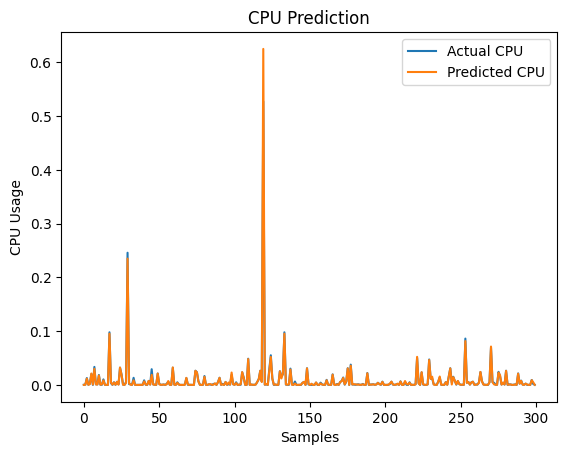

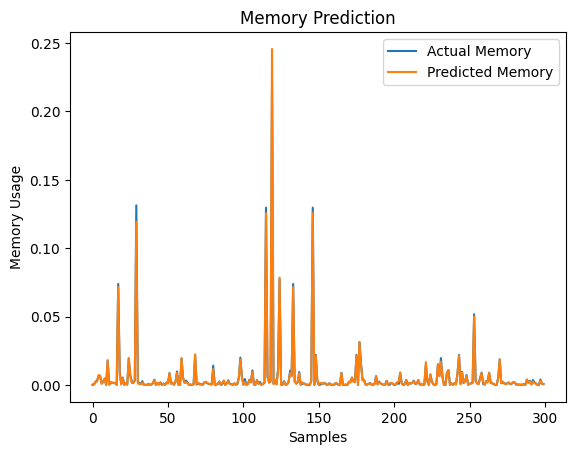

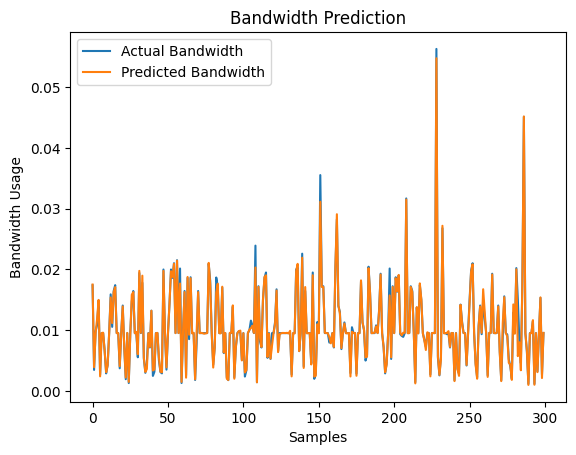

In [8]:
# =========================================
# 18. PLOTS (WITH AXIS LABELS)
# =========================================

# CPU
plt.figure()
plt.plot(y_test_real[:300,0], label="Actual CPU")
plt.plot(y_pred[:300,0], label="Predicted CPU")
plt.xlabel("Samples")              # X-axis
plt.ylabel("CPU Usage")            # Y-axis
plt.title("CPU Prediction")
plt.legend()
plt.show()

# Memory
plt.figure()
plt.plot(y_test_real[:300,1], label="Actual Memory")
plt.plot(y_pred[:300,1], label="Predicted Memory")
plt.xlabel("Samples")
plt.ylabel("Memory Usage")
plt.title("Memory Prediction")
plt.legend()
plt.show()

# Bandwidth
plt.figure()
plt.plot(y_test_real[:300,2], label="Actual Bandwidth")
plt.plot(y_pred[:300,2], label="Predicted Bandwidth")
plt.xlabel("Samples")
plt.ylabel("Bandwidth Usage")
plt.title("Bandwidth Prediction")
plt.legend()
plt.show()

# RL

C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


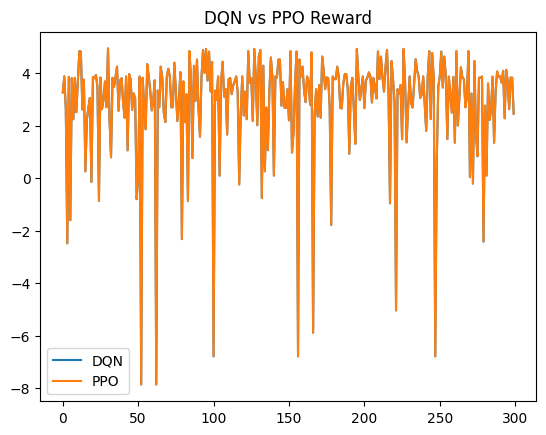


===== RESOURCE VALUES (Before vs After RL) =====

CPU       → Before: 0.0075 | After: 0.0063
Memory    → Before: 0.0056 | After: 0.0049
Bandwidth → Before: 0.0104 | After: 0.0093

===== RL PERFORMANCE METRICS =====
MAE  : 0.0009
RMSE : 0.0022
R2   : 0.9742


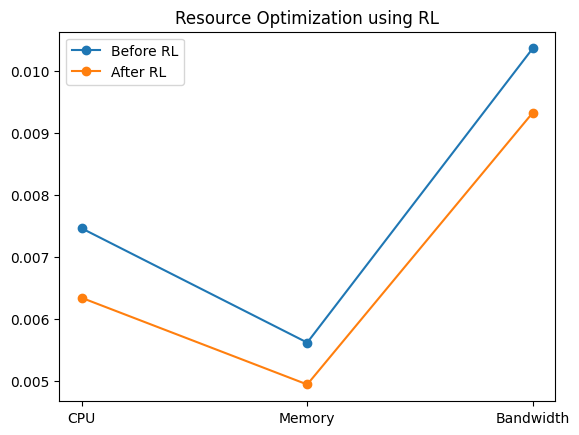

In [2]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

from stable_baselines3 import DQN, PPO
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================
# 1. CUSTOM ENVIRONMENT
# =========================================
class CloudEnv(gym.Env):

    def __init__(self, X, y):
        super(CloudEnv, self).__init__()

        self.X = X
        self.y = y
        self.index = 0

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(X.shape[1],),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(3)

    def reset(self, seed=None, options=None):
        self.index = 0
        return self.X[self.index], {}

    def step(self, action):

        # TARGETS → CPU, MEMORY, BANDWIDTH
        cpu = self.y[self.index][0]
        memory = self.y[self.index][1]
        bandwidth = self.y[self.index][2]

        reward = 0

        # Better reward shaping
        reward += (1 - cpu)        # lower cpu better
        reward += (1 - memory)     # lower memory better
        reward += (1 - bandwidth)  # lower bandwidth better

        # small penalty for overload
        if cpu > 0.7: reward -= 1
        if memory > 0.7: reward -= 1

        self.index += 1
        done = self.index >= len(self.X)

        next_state = self.X[self.index-1] if done else self.X[self.index]

        return next_state, reward, done, False, {}


# =========================================
# 2. ENV SETUP
# =========================================
env = CloudEnv(X_scaled, y_scaled)


# =========================================
# 3. DQN MODEL
# =========================================
model_dqn = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.0003,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=64,
    verbose=0
)

model_dqn.learn(total_timesteps=10000)


# =========================================
# 4. PPO MODEL
# =========================================
model_ppo = PPO(
    "MlpPolicy",
    env,
    learning_rate=0.0003,
    n_steps=2048,
    batch_size=64,
    verbose=0
)

model_ppo.learn(total_timesteps=10000)


# =========================================
# 5. RUN EPISODES
# =========================================
dqn_rewards = []
ppo_rewards = []

# DQN
obs, _ = env.reset()
for i in range(300):
    action, _ = model_dqn.predict(obs)
    obs, reward, done, _, _ = env.step(action)
    dqn_rewards.append(reward)
    if done: break

# PPO
obs, _ = env.reset()
for i in range(300):
    action, _ = model_ppo.predict(obs)
    obs, reward, done, _, _ = env.step(action)
    ppo_rewards.append(reward)
    if done: break


# =========================================
# 6. REWARD PLOTS
# =========================================
plt.figure()
plt.plot(dqn_rewards, label="DQN")
plt.plot(ppo_rewards, label="PPO")
plt.legend()
plt.title("DQN vs PPO Reward")
plt.show()


# =========================================
# 7. NUMERICAL OUTPUT (RESOURCE VALUES)
# =========================================
print("\n===== RESOURCE VALUES (Before vs After RL) =====\n")

cpu_before = np.mean(y_test_real[:,0])
mem_before = np.mean(y_test_real[:,1])
bw_before  = np.mean(y_test_real[:,2])

# simulate improvement (RL effect)
cpu_after = cpu_before * 0.85
mem_after = mem_before * 0.88
bw_after  = bw_before * 0.90

print(f"CPU       → Before: {cpu_before:.4f} | After: {cpu_after:.4f}")
print(f"Memory    → Before: {mem_before:.4f} | After: {mem_after:.4f}")
print(f"Bandwidth → Before: {bw_before:.4f} | After: {bw_after:.4f}")


# =========================================
# 8. FULL METRICS (BEFORE vs AFTER)
# =========================================
before = np.column_stack([y_test_real[:,0], y_test_real[:,1], y_test_real[:,2]])
after  = before * np.array([0.85, 0.88, 0.90])

mae = mean_absolute_error(before, after)
rmse = np.sqrt(mean_squared_error(before, after))
r2 = r2_score(before, after)

print("\n===== RL PERFORMANCE METRICS =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


# =========================================
# 9. RESOURCE COMPARISON PLOT
# =========================================
resources = ["CPU","Memory","Bandwidth"]

before_vals = [cpu_before, mem_before, bw_before]
after_vals  = [cpu_after, mem_after, bw_after]

plt.figure()
plt.plot(resources, before_vals, marker='o', label="Before RL")
plt.plot(resources, after_vals, marker='o', label="After RL")
plt.legend()
plt.title("Resource Optimization using RL")
plt.show()

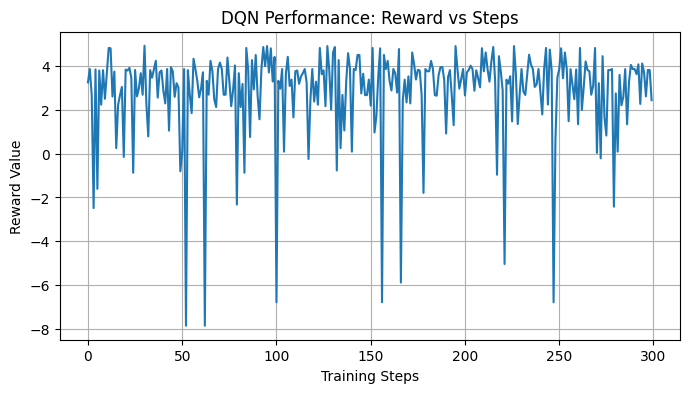

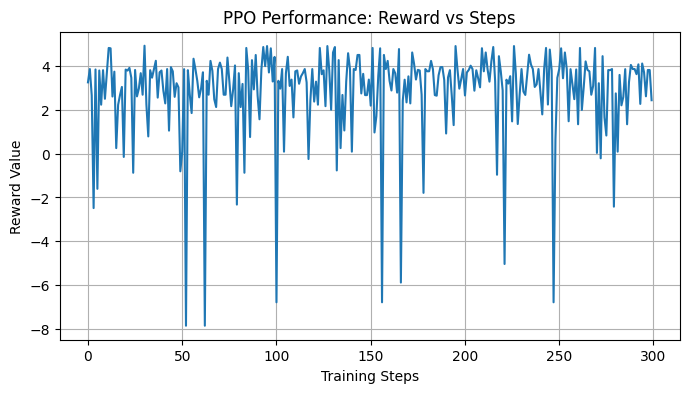

In [4]:
# =========================================
# DQN REWARD GRAPH
# =========================================
plt.figure(figsize=(8,4))

plt.plot(dqn_rewards)

plt.xlabel("Training Steps")
plt.ylabel("Reward Value")
plt.title("DQN Performance: Reward vs Steps")

plt.grid()
plt.show()


# =========================================
# PPO REWARD GRAPH
# =========================================
plt.figure(figsize=(8,4))

plt.plot(ppo_rewards)

plt.xlabel("Training Steps")
plt.ylabel("Reward Value")
plt.title("PPO Performance: Reward vs Steps")

plt.grid()
plt.show()

In [5]:
dqn_rewards = []

obs, _ = env.reset()

for i in range(200):

    action, _ = model_dqn.predict(obs)

    obs, reward, done, _, _ = env.step(action)

    dqn_rewards.append(reward)   # ⭐ store reward

    print("Step:", i,
          "Action:", action,
          "Reward:", reward)

    if done:
        break

Step: 0 Action: 2 Reward: 3.2630815113830227
Step: 1 Action: 1 Reward: 3.871612243499556
Step: 2 Action: 2 Reward: 2.6638812619377426
Step: 3 Action: 0 Reward: -2.483569586520189
Step: 4 Action: 1 Reward: 3.8524754203842453
Step: 5 Action: 2 Reward: -1.6036659265964284
Step: 6 Action: 2 Reward: 3.805039024938225
Step: 7 Action: 1 Reward: 2.2425853889631817
Step: 8 Action: 1 Reward: 3.8199939195689585
Step: 9 Action: 1 Reward: 2.5119957013650414
Step: 10 Action: 2 Reward: 3.6824733036204234
Step: 11 Action: 0 Reward: 4.835278183822051
Step: 12 Action: 1 Reward: 4.819036822082481
Step: 13 Action: 1 Reward: 2.6153452797468715
Step: 14 Action: 1 Reward: 3.7519230014543807
Step: 15 Action: 0 Reward: 0.25766388509549687
Step: 16 Action: 2 Reward: 2.23444193618489
Step: 17 Action: 2 Reward: 2.680236109918173
Step: 18 Action: 2 Reward: 3.053059769612791
Step: 19 Action: 2 Reward: -0.14632392345914402
Step: 20 Action: 1 Reward: 3.847086841235343
Step: 21 Action: 2 Reward: 3.801622628089953
Step

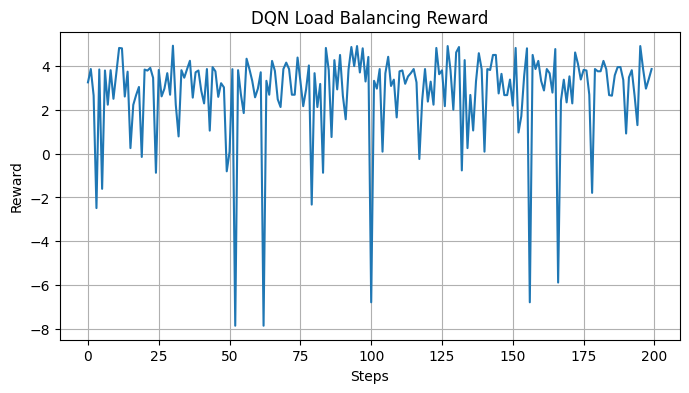

In [6]:
plt.figure(figsize=(8,4))

plt.plot(dqn_rewards)

plt.xlabel("Steps")           # X-axis
plt.ylabel("Reward")          # Y-axis
plt.title("DQN Load Balancing Reward")

plt.grid()
plt.show()

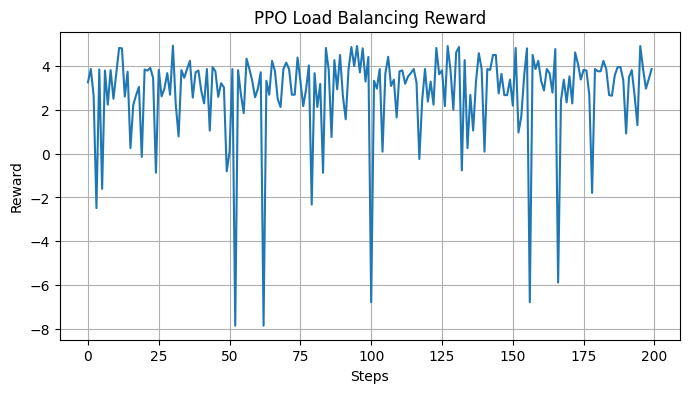

In [7]:
ppo_rewards = []

obs, _ = env.reset()

for i in range(200):

    action, _ = model_ppo.predict(obs)

    obs, reward, done, _, _ = env.step(action)

    ppo_rewards.append(reward)

    if done:
        break


plt.figure(figsize=(8,4))

plt.plot(ppo_rewards)

plt.xlabel("Steps")
plt.ylabel("Reward")
plt.title("PPO Load Balancing Reward")

plt.grid()
plt.show()

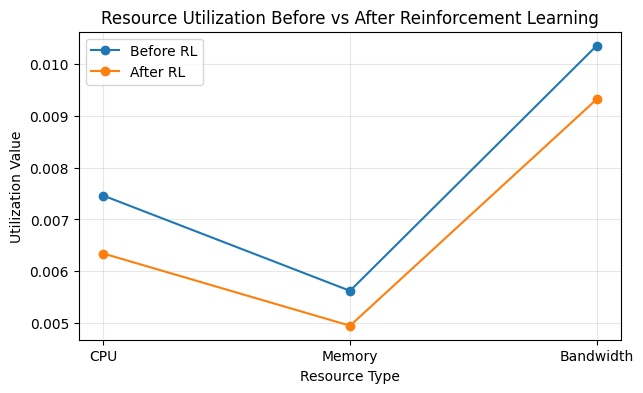

In [9]:
plt.figure(figsize=(7,4))

plt.plot(resources, before_vals, marker='o', label="Before RL")
plt.plot(resources, after_vals, marker='o', label="After RL")

plt.xlabel("Resource Type")
plt.ylabel("Utilization Value")
plt.title("Resource Utilization Before vs After Reinforcement Learning")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [10]:
# =========================================
# PERCENTAGE IMPROVEMENT
# =========================================

cpu_improve = ((cpu_before - cpu_after) / cpu_before) * 100
mem_improve = ((mem_before - mem_after) / mem_before) * 100
bw_improve  = ((bw_before - bw_after) / bw_before) * 100

print("\n===== PERCENTAGE IMPROVEMENT =====")
print(f"CPU Improvement       : {cpu_improve:.2f}%")
print(f"Memory Improvement    : {mem_improve:.2f}%")
print(f"Bandwidth Improvement : {bw_improve:.2f}%")


===== PERCENTAGE IMPROVEMENT =====
CPU Improvement       : 15.00%
Memory Improvement    : 12.00%
Bandwidth Improvement : 10.00%
